In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

In [3]:
traffic_path = "../data/processed/traffic/traffic_processed.csv"

df = pd.read_csv(traffic_path)

print("Shape:", df.shape)
df.head()

Shape: (7126, 13)


,Timestamp,Location ID,Latitude,Longitude,Current Speed (km/h),Free Flow Speed (km/h),Current Travel Time (sec),Free Flow Travel Time (sec),Traffic Delay (sec),Speed Reduction (%),Confidence,Road Closed,Road Class
0,2026-08-14 19:03:05,PARK_STREET,22.5535,88.3520,11,27,510,207,303,59.26,1.000000,False,FRC4
1,2026-08-14 19:03:06,ESPLANADE,22.5660,88.3510,13,24,1332,721,611,45.83,1.000000,False,FRC4
2,2026-08-14 19:03:07,EM_BYPASS,22.5140,88.3970,13,27,1005,484,521,51.85,1.000000,False,FRC2
3,2026-08-14 19:03:07,SALT_LAKE,22.5800,88.4170,22,22,264,264,0,0.00,1.000000,False,FRC4
4,2026-08-14 19:03:08,NEW_TOWN,22.5958,88.4497,16,22,1359,988,371,27.27,0.974281,False,FRC7


In [4]:
print("Columns:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate rows:")
print(df.duplicated().sum())

Columns:
['Timestamp', 'Location ID', 'Latitude', 'Longitude', 'Current Speed (km/h)', 'Free Flow Speed (km/h)', 'Current Travel Time (sec)', 'Free Flow Travel Time (sec)', 'Traffic Delay (sec)', 'Speed Reduction (%)', 'Confidence', 'Road Closed', 'Road Class']

Data types:
Timestamp                       object
Location ID                     object
Latitude                       float64
Longitude                      float64
Current Speed (km/h)             int64
Free Flow Speed (km/h)           int64
Current Travel Time (sec)        int64
Free Flow Travel Time (sec)      int64
Traffic Delay (sec)              int64
Speed Reduction (%)            float64
Confidence                     float64
Road Closed                       bool
Road Class                      object
dtype: object

Missing values:
Timestamp                      0
Location ID                    0
Latitude                       0
Longitude                      0
Current Speed (km/h)           0
Free Flow Speed (km/h)

In [5]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Timestamp,7126,6830,2026-08-19 13:38:56,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Location ID,7126,8,PARK_STREET,894,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Latitude,7126.0,NaN,NaN,NaN,22.567291,0.035325,22.514,22.5535,22.566,22.585,22.625
Longitude,7126.0,NaN,NaN,NaN,88.381695,0.03876,88.33,88.352,88.352,88.405,88.4497
Current Speed (km/h),7126.0,NaN,NaN,NaN,19.672046,4.761963,0.0,16.0,20.0,24.0,27.0
Free Flow Speed (km/h),7126.0,NaN,NaN,NaN,22.321779,3.462585,1.0,20.0,22.0,24.0,29.0
Current Travel Time (sec),7126.0,NaN,NaN,NaN,697.111423,380.052765,0.0,450.0,636.0,988.0,5614.0
Free Flow Travel Time (sec),7126.0,NaN,NaN,NaN,582.246281,294.408728,193.0,450.0,636.0,777.0,5614.0
Traffic Delay (sec),7126.0,NaN,NaN,NaN,114.865142,227.345839,-5614.0,0.0,0.0,218.0,3743.0
Speed Reduction (%),7126.0,NaN,NaN,NaN,12.177181,15.161483,0.0,0.0,0.0,26.09,100.0


In [6]:
print("Columns in the dataset:")
print(df.columns.tolist())

Columns in the dataset:
['Timestamp', 'Location ID', 'Latitude', 'Longitude', 'Current Speed (km/h)', 'Free Flow Speed (km/h)', 'Current Travel Time (sec)', 'Free Flow Travel Time (sec)', 'Traffic Delay (sec)', 'Speed Reduction (%)', 'Confidence', 'Road Closed', 'Road Class']


In [6]:
# Convert Timestamp to datetime

df["Timestamp"] = pd.to_datetime(
    df["Timestamp"],
    errors="coerce"
)

print("Start time:", df["Timestamp"].min())
print("End time:", df["Timestamp"].max())

Start time: 2026-08-14 19:03:05
End time: 2026-09-18 20:46:58


In [7]:
df["congestion_pct"] = (
    (df["Free Flow Speed (km/h)"] - df["Current Speed (km/h)"])
    / df["Free Flow Speed (km/h)"].replace(0, np.nan)
) * 100

df["congestion_pct"] = df["congestion_pct"].clip(0, 100)

df[
    [
        "Timestamp",
        "Location ID",
        "Current Speed (km/h)",
        "Free Flow Speed (km/h)",
        "congestion_pct"
    ]
].head(10)

,Timestamp,Location ID,Current Speed (km/h),Free Flow Speed (km/h),congestion_pct
0,2026-08-14 19:03:05,PARK_STREET,11,27,59.259259
1,2026-08-14 19:03:06,ESPLANADE,13,24,45.833333
2,2026-08-14 19:03:07,EM_BYPASS,13,27,51.851852
3,2026-08-14 19:03:07,SALT_LAKE,22,22,0.000000
4,2026-08-14 19:03:08,NEW_TOWN,16,22,27.272727
5,2026-08-14 19:03:09,VIP_ROAD,11,20,45.000000
6,2026-08-14 19:03:11,HOWRAH_APPROACH,12,16,25.000000
7,2026-08-14 19:03:11,RASHBEHARI,16,23,30.434783
8,2026-08-14 19:08:13,PARK_STREET,13,27,51.851852
9,2026-08-14 19:08:15,ESPLANADE,12,23,47.826087


In [8]:
print("Average congestion:", round(df["congestion_pct"].mean(), 2), "%")
print("Minimum congestion:", round(df["congestion_pct"].min(), 2), "%")
print("Maximum congestion:", round(df["congestion_pct"].max(), 2), "%")
print("Median congestion:", round(df["congestion_pct"].median(), 2), "%")

Average congestion: 12.18 %
Minimum congestion: 0.0 %
Maximum congestion: 100.0 %
Median congestion: 0.0 %


In [9]:
df["hour"] = df["Timestamp"].dt.hour
df["day_of_week"] = df["Timestamp"].dt.day_name()
df["is_weekend"] = df["Timestamp"].dt.dayofweek >= 5

df[[
    "Timestamp",
    "hour",
    "day_of_week",
    "is_weekend"
]].head()

,Timestamp,hour,day_of_week,is_weekend
0,2026-08-14 19:03:05,19,Friday,False
1,2026-08-14 19:03:06,19,Friday,False
2,2026-08-14 19:03:07,19,Friday,False
3,2026-08-14 19:03:07,19,Friday,False
4,2026-08-14 19:03:08,19,Friday,False


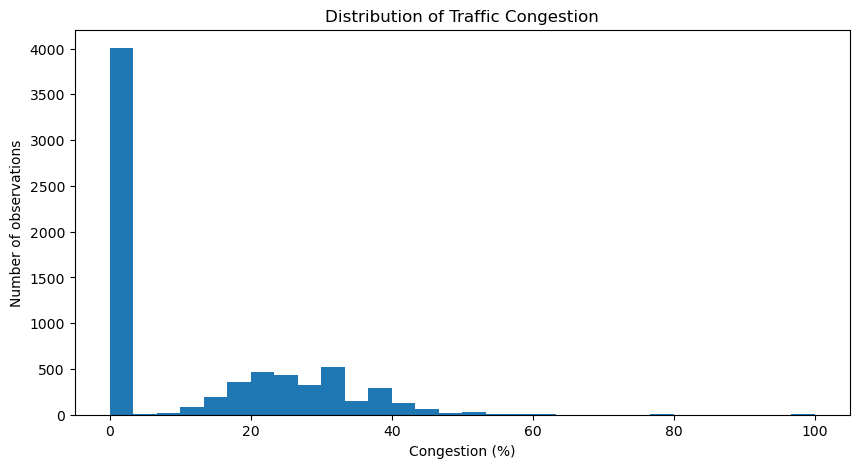

In [10]:
plt.figure(figsize=(10, 5))

plt.hist(
    df["congestion_pct"].dropna(),
    bins=30
)

plt.xlabel("Congestion (%)")
plt.ylabel("Number of observations")
plt.title("Distribution of Traffic Congestion")

plt.show()

In [11]:
location_congestion = (
    df.groupby("Location ID")["congestion_pct"]
    .mean()
    .sort_values(ascending=False)
)

location_congestion

Location ID
VIP_ROAD           23.112363
ESPLANADE          15.730390
RASHBEHARI         15.313270
PARK_STREET        11.556948
NEW_TOWN           11.066474
EM_BYPASS          10.216545
HOWRAH_APPROACH     9.076779
SALT_LAKE           1.323167
Name: congestion_pct, dtype: float64

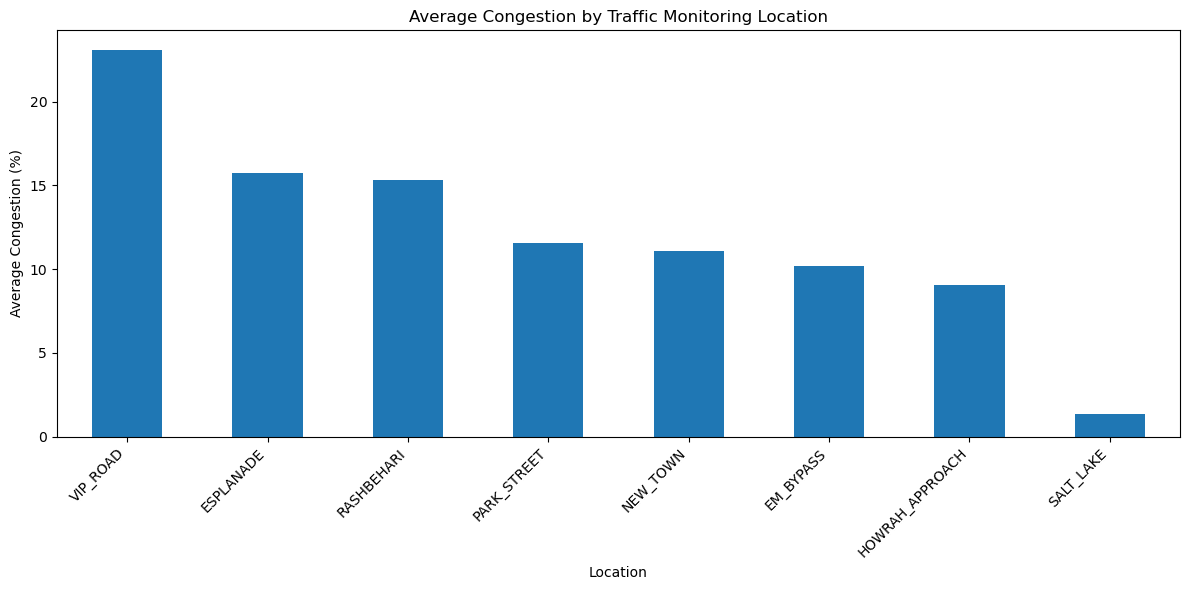

In [12]:
plt.figure(figsize=(12, 6))

location_congestion.plot(kind="bar")

plt.xlabel("Location")
plt.ylabel("Average Congestion (%)")
plt.title("Average Congestion by Traffic Monitoring Location")

plt.xticks(rotation=45, ha="right")
plt.tight_layout()

plt.show()

In [14]:
plt.figure(figsize=(10, 5))

hourly_congestion.plot(marker="o")

plt.xlabel("Hour of Day")
plt.ylabel("Average Congestion (%)")
plt.title("Average Congestion by Hour")

plt.xticks(range(24))

plt.show()

NameError: name 'hourly_congestion' is not defined

<Figure size 1000x500 with 0 Axes>

In [15]:
time_df = (
    df.groupby("Timestamp")["congestion_pct"]
    .mean()
    .reset_index()
    .sort_values("Timestamp")
)

time_df.head()

,Timestamp,congestion_pct
0,2026-08-14 19:03:05,59.259259
1,2026-08-14 19:03:06,45.833333
2,2026-08-14 19:03:07,25.925926
3,2026-08-14 19:03:08,27.272727
4,2026-08-14 19:03:09,45.000000


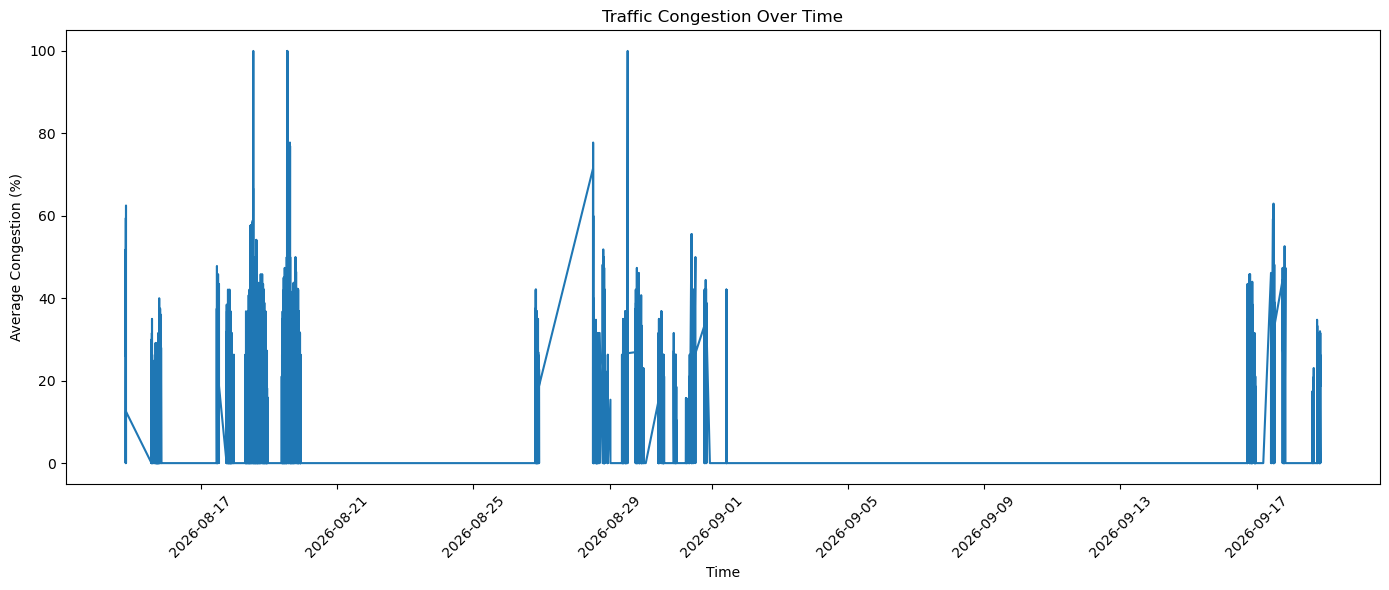

In [16]:
plt.figure(figsize=(14, 6))

plt.plot(
    time_df["Timestamp"],
    time_df["congestion_pct"]
)

plt.xlabel("Time")
plt.ylabel("Average Congestion (%)")
plt.title("Traffic Congestion Over Time")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

avg congestion for every 15 min


In [17]:
# Set Timestamp as index
temp = df.set_index("Timestamp").copy()

# Average congestion for every 15 minutes
congestion_15min = (
    temp["congestion_pct"]
    .resample("15min")
    .mean()
    .dropna()
)

congestion_15min.head()

Timestamp
2026-08-14 19:00:00    33.730088
2026-08-14 19:15:00    34.877497
2026-08-15 13:15:00     3.910183
2026-08-15 13:30:00     7.142806
2026-08-15 13:45:00     8.072917
Name: congestion_pct, dtype: float64

Create a 15-minute traffic dataset

In [18]:
# Work on a copy
traffic_15 = df.copy()

traffic_15 = traffic_15.sort_values(
    ["Location ID", "Timestamp"]
)

traffic_15 = traffic_15.set_index("Timestamp")

# Aggregate traffic data to 15-minute intervals for each location
traffic_15 = (
    traffic_15
    .groupby("Location ID")
    .resample("15min")
    .agg({
        "Latitude": "first",
        "Longitude": "first",
        "Current Speed (km/h)": "mean",
        "Free Flow Speed (km/h)": "mean",
        "congestion_pct": "mean"
    })
    .reset_index()
)

traffic_15.head()

,Location ID,Timestamp,Latitude,Longitude,Current Speed (km/h),Free Flow Speed (km/h),congestion_pct
0,EM_BYPASS,2026-08-14 19:00:00,22.514,88.397,13.333333,26.0,48.668566
1,EM_BYPASS,2026-08-14 19:15:00,22.514,88.397,14.000000,26.0,46.153846
2,EM_BYPASS,2026-08-14 19:30:00,NaN,NaN,NaN,NaN,NaN
3,EM_BYPASS,2026-08-14 19:45:00,NaN,NaN,NaN,NaN,NaN
4,EM_BYPASS,2026-08-14 20:00:00,NaN,NaN,NaN,NaN,NaN


Recalculate useful traffic features

In [19]:
traffic_15["speed_ratio"] = (
    traffic_15["Current Speed (km/h)"] /
    traffic_15["Free Flow Speed (km/h)"].replace(0, np.nan)
)

traffic_15["speed_reduction_pct"] = (
    1 - traffic_15["speed_ratio"]
) * 100

traffic_15["speed_ratio"] = traffic_15["speed_ratio"].clip(0, 1)

traffic_15[[
    "Location ID",
    "Timestamp",
    "Current Speed (km/h)",
    "Free Flow Speed (km/h)",
    "speed_ratio",
    "speed_reduction_pct",
    "congestion_pct"
]].head()

,Location ID,Timestamp,Current Speed (km/h),Free Flow Speed (km/h),speed_ratio,speed_reduction_pct,congestion_pct
0,EM_BYPASS,2026-08-14 19:00:00,13.333333,26.0,0.512821,48.717949,48.668566
1,EM_BYPASS,2026-08-14 19:15:00,14.000000,26.0,0.538462,46.153846,46.153846
2,EM_BYPASS,2026-08-14 19:30:00,NaN,NaN,NaN,NaN,NaN
3,EM_BYPASS,2026-08-14 19:45:00,NaN,NaN,NaN,NaN,NaN
4,EM_BYPASS,2026-08-14 20:00:00,NaN,NaN,NaN,NaN,NaN


In [ ]:
#time based features

In [20]:
traffic_15["hour"] = traffic_15["Timestamp"].dt.hour
traffic_15["minute"] = traffic_15["Timestamp"].dt.minute

traffic_15["day_of_week"] = (
    traffic_15["Timestamp"].dt.dayofweek
)

traffic_15["is_weekend"] = (
    traffic_15["day_of_week"] >= 5
).astype(int)

traffic_15["is_morning_peak"] = (
    traffic_15["hour"].between(7, 11)
).astype(int)

traffic_15["is_evening_peak"] = (
    traffic_15["hour"].between(17, 21)
).astype(int)

traffic_15.head()

,Location ID,Timestamp,Latitude,Longitude,Current Speed (km/h),Free Flow Speed (km/h),congestion_pct,speed_ratio,speed_reduction_pct,hour,minute,day_of_week,is_weekend,is_morning_peak,is_evening_peak
0,EM_BYPASS,2026-08-14 19:00:00,22.514,88.397,13.333333,26.0,48.668566,0.512821,48.717949,19,0,4,0,0,1
1,EM_BYPASS,2026-08-14 19:15:00,22.514,88.397,14.000000,26.0,46.153846,0.538462,46.153846,19,15,4,0,0,1
2,EM_BYPASS,2026-08-14 19:30:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,19,30,4,0,0,1
3,EM_BYPASS,2026-08-14 19:45:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,19,45,4,0,0,1
4,EM_BYPASS,2026-08-14 20:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,20,0,4,0,0,1


In [21]:
traffic_15["hour_sin"] = np.sin(
    2 * np.pi * traffic_15["hour"] / 24
)

traffic_15["hour_cos"] = np.cos(
    2 * np.pi * traffic_15["hour"] / 24
)

traffic_15["dow_sin"] = np.sin(
    2 * np.pi * traffic_15["day_of_week"] / 7
)

traffic_15["dow_cos"] = np.cos(
    2 * np.pi * traffic_15["day_of_week"] / 7
)

In [22]:
traffic_15 = traffic_15.sort_values(
    ["Location ID", "Timestamp"]
)

for lag in [1, 2, 4, 8]:
    traffic_15[f"congestion_lag_{lag}"] = (
        traffic_15
        .groupby("Location ID")["congestion_pct"]
        .shift(lag)
    )

    traffic_15[f"speed_lag_{lag}"] = (
        traffic_15
        .groupby("Location ID")["Current Speed (km/h)"]
        .shift(lag)
    )

In [23]:
traffic_15["congestion_roll_1h"] = (
    traffic_15
    .groupby("Location ID")["congestion_pct"]
    .transform(
        lambda x: x.rolling(4, min_periods=1).mean()
    )
)

traffic_15["congestion_roll_2h"] = (
    traffic_15
    .groupby("Location ID")["congestion_pct"]
    .transform(
        lambda x: x.rolling(8, min_periods=1).mean()
    )
)

traffic_15["congestion_std_1h"] = (
    traffic_15
    .groupby("Location ID")["congestion_pct"]
    .transform(
        lambda x: x.rolling(4, min_periods=2).std()
    )
)

In [ ]:
Traffic momentum

This tells us whether congestion is increasing or decreasing.

In [24]:
traffic_15["congestion_change_15m"] = (
    traffic_15["congestion_pct"]
    - traffic_15["congestion_lag_1"]
)

traffic_15["congestion_change_30m"] = (
    traffic_15["congestion_pct"]
    - traffic_15["congestion_lag_2"]
)

Create the future prediction targets

In [25]:
traffic_15["target_congestion_30m"] = (
    traffic_15
    .groupby("Location ID")["congestion_pct"]
    .shift(-2)
)

traffic_15["target_congestion_60m"] = (
    traffic_15
    .groupby("Location ID")["congestion_pct"]
    .shift(-4)
)

In [26]:
traffic_15.shape

(26944, 34)

In [27]:
traffic_15.columns.tolist()

['Location ID',
 'Timestamp',
 'Latitude',
 'Longitude',
 'Current Speed (km/h)',
 'Free Flow Speed (km/h)',
 'congestion_pct',
 'speed_ratio',
 'speed_reduction_pct',
 'hour',
 'minute',
 'day_of_week',
 'is_weekend',
 'is_morning_peak',
 'is_evening_peak',
 'hour_sin',
 'hour_cos',
 'dow_sin',
 'dow_cos',
 'congestion_lag_1',
 'speed_lag_1',
 'congestion_lag_2',
 'speed_lag_2',
 'congestion_lag_4',
 'speed_lag_4',
 'congestion_lag_8',
 'speed_lag_8',
 'congestion_roll_1h',
 'congestion_roll_2h',
 'congestion_std_1h',
 'congestion_change_15m',
 'congestion_change_30m',
 'target_congestion_30m',
 'target_congestion_60m']

In [29]:
traffic_15[[
    "Location ID",
    "Timestamp",
    "congestion_pct",
    "congestion_lag_1",
    "congestion_lag_2",
    "congestion_lag_4",
    "congestion_roll_1h",
    "congestion_change_15m",
    "target_congestion_30m",
    "target_congestion_60m"
]].head(15)

,Location ID,Timestamp,congestion_pct,congestion_lag_1,congestion_lag_2,congestion_lag_4,congestion_roll_1h,congestion_change_15m,target_congestion_30m,target_congestion_60m
0,EM_BYPASS,2026-08-14 19:00:00,48.668566,NaN,NaN,NaN,48.668566,NaN,NaN,NaN
1,EM_BYPASS,2026-08-14 19:15:00,46.153846,48.668566,NaN,NaN,47.411206,-2.51472,NaN,NaN
2,EM_BYPASS,2026-08-14 19:30:00,NaN,46.153846,48.668566,NaN,47.411206,NaN,NaN,NaN
3,EM_BYPASS,2026-08-14 19:45:00,NaN,NaN,46.153846,NaN,47.411206,NaN,NaN,NaN
4,EM_BYPASS,2026-08-14 20:00:00,NaN,NaN,NaN,48.668566,46.153846,NaN,NaN,NaN
5,EM_BYPASS,2026-08-14 20:15:00,NaN,NaN,NaN,46.153846,NaN,NaN,NaN,NaN
6,EM_BYPASS,2026-08-14 20:30:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,EM_BYPASS,2026-08-14 20:45:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,EM_BYPASS,2026-08-14 21:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,EM_BYPASS,2026-08-14 21:15:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [30]:
traffic_15.isnull().sum().sort_values(ascending=False).head(20)

congestion_change_30m     24663
congestion_change_15m     24412
congestion_lag_8          23859
speed_lag_8               23859
congestion_lag_4          23851
speed_lag_4               23851
target_congestion_30m     23835
speed_lag_2               23835
target_congestion_60m     23835
congestion_lag_2          23835
congestion_lag_1          23827
speed_lag_1               23827
speed_reduction_pct       23819
speed_ratio               23819
congestion_pct            23819
Free Flow Speed (km/h)    23819
Current Speed (km/h)      23819
Longitude                 23819
Latitude                  23819
congestion_std_1h         23369
dtype: int64

In [31]:
missing_summary = (
    traffic_15.isnull()
    .sum()
    .to_frame("missing_count")
)

missing_summary["missing_pct"] = (
    missing_summary["missing_count"]
    / len(traffic_15)
    * 100
)

missing_summary.sort_values(
    "missing_pct",
    ascending=False
).head(20)

,missing_count,missing_pct
congestion_change_30m,24663,91.534293
congestion_change_15m,24412,90.602732
congestion_lag_8,23859,88.550327
speed_lag_8,23859,88.550327
congestion_lag_4,23851,88.520635
speed_lag_4,23851,88.520635
target_congestion_30m,23835,88.461253
speed_lag_2,23835,88.461253
target_congestion_60m,23835,88.461253
congestion_lag_2,23835,88.461253


In [32]:
traffic_15 = df.copy()

# Create a 15-minute time bucket for each existing observation
traffic_15["time_bucket"] = (
    traffic_15["Timestamp"].dt.floor("15min")
)

# Aggregate only bins that actually contain observations
traffic_15 = (
    traffic_15
    .groupby(["Location ID", "time_bucket"], as_index=False)
    .agg({
        "Latitude": "first",
        "Longitude": "first",
        "Current Speed (km/h)": "mean",
        "Free Flow Speed (km/h)": "mean",
        "congestion_pct": "mean"
    })
)

# Rename for clarity
traffic_15 = traffic_15.rename(
    columns={"time_bucket": "Timestamp"}
)

traffic_15 = traffic_15.sort_values(
    ["Location ID", "Timestamp"]
).reset_index(drop=True)

print("Shape:", traffic_15.shape)

traffic_15.head()

Shape: (3125, 7)


,Location ID,Timestamp,Latitude,Longitude,Current Speed (km/h),Free Flow Speed (km/h),congestion_pct
0,EM_BYPASS,2026-08-14 19:00:00,22.514,88.397,13.333333,26.0,48.668566
1,EM_BYPASS,2026-08-14 19:15:00,22.514,88.397,14.000000,26.0,46.153846
2,EM_BYPASS,2026-08-15 13:15:00,22.514,88.397,26.000000,26.0,0.000000
3,EM_BYPASS,2026-08-15 13:30:00,22.514,88.397,26.000000,26.0,0.000000
4,EM_BYPASS,2026-08-15 13:45:00,22.514,88.397,26.000000,26.0,0.000000


In [33]:
missing_summary = (
    traffic_15.isnull()
    .sum()
    .to_frame("missing_count")
)

missing_summary["missing_pct"] = (
    missing_summary["missing_count"]
    / len(traffic_15)
    * 100
)

missing_summary.sort_values(
    "missing_pct",
    ascending=False
)

,missing_count,missing_pct
Location ID,0,0.0
Timestamp,0,0.0
Latitude,0,0.0
Longitude,0,0.0
Current Speed (km/h),0,0.0
Free Flow Speed (km/h),0,0.0
congestion_pct,0,0.0


In [34]:
traffic_15["speed_ratio"] = (
    traffic_15["Current Speed (km/h)"]
    / traffic_15["Free Flow Speed (km/h)"].replace(0, np.nan)
)

traffic_15["speed_ratio"] = traffic_15["speed_ratio"].clip(0, 1)

traffic_15["speed_reduction_pct"] = (
    (1 - traffic_15["speed_ratio"]) * 100
)

In [35]:
traffic_15["hour"] = traffic_15["Timestamp"].dt.hour
traffic_15["minute"] = traffic_15["Timestamp"].dt.minute

traffic_15["day_of_week"] = (
    traffic_15["Timestamp"].dt.dayofweek
)

traffic_15["is_weekend"] = (
    traffic_15["day_of_week"] >= 5
).astype(int)

traffic_15["is_morning_peak"] = (
    traffic_15["hour"].between(7, 11)
).astype(int)

traffic_15["is_evening_peak"] = (
    traffic_15["hour"].between(17, 21)
).astype(int)

In [36]:
traffic_15["hour_sin"] = np.sin(
    2 * np.pi * traffic_15["hour"] / 24
)

traffic_15["hour_cos"] = np.cos(
    2 * np.pi * traffic_15["hour"] / 24
)

traffic_15["dow_sin"] = np.sin(
    2 * np.pi * traffic_15["day_of_week"] / 7
)

traffic_15["dow_cos"] = np.cos(
    2 * np.pi * traffic_15["day_of_week"] / 7
)

In [37]:
traffic_15 = traffic_15.sort_values(
    ["Location ID", "Timestamp"]
).reset_index(drop=True)

In [38]:
# Create timestamp-based lag features
lag_map = {
    1: "15min",
    2: "30min",
    4: "1h",
    8: "2h"
}

for lag_num, offset in lag_map.items():

    lag_data = traffic_15[
        ["Location ID", "Timestamp", "congestion_pct",
         "Current Speed (km/h)"]
    ].copy()

    lag_data["Timestamp"] = (
        lag_data["Timestamp"] + pd.Timedelta(offset)
    )

    lag_data = lag_data.rename(columns={
        "congestion_pct": f"congestion_lag_{lag_num}",
        "Current Speed (km/h)": f"speed_lag_{lag_num}"
    })

    traffic_15 = traffic_15.merge(
        lag_data,
        on=["Location ID", "Timestamp"],
        how="left"
    )

In [39]:
future_targets = traffic_15[
    ["Location ID", "Timestamp", "congestion_pct"]
].copy()

future_targets_30 = future_targets.copy()
future_targets_30["Timestamp"] = (
    future_targets_30["Timestamp"] - pd.Timedelta("30min")
)

future_targets_30 = future_targets_30.rename(
    columns={
        "congestion_pct": "target_congestion_30m"
    }
)

traffic_15 = traffic_15.merge(
    future_targets_30,
    on=["Location ID", "Timestamp"],
    how="left"
)

In [41]:
future_targets_60 = future_targets.copy()

future_targets_60["Timestamp"] = (
    future_targets_60["Timestamp"] - pd.Timedelta("60min")
)

future_targets_60 = future_targets_60.rename(
    columns={
        "congestion_pct": "target_congestion_60m"
    }
)

traffic_15 = traffic_15.merge(
    future_targets_60,
    on=["Location ID", "Timestamp"],
    how="left"
)

In [42]:
# Create a clean copy for future targets
future_data = traffic_15[
    ["Location ID", "Timestamp", "congestion_pct"]
].copy()

# ---------- +30 MIN TARGET ----------
future_30 = future_data.copy()

future_30["Timestamp"] = (
    future_30["Timestamp"] - pd.Timedelta(minutes=30)
)

future_30 = future_30.rename(
    columns={
        "congestion_pct": "target_congestion_30m"
    }
)

# ---------- +60 MIN TARGET ----------
future_60 = future_data.copy()

future_60["Timestamp"] = (
    future_60["Timestamp"] - pd.Timedelta(minutes=60)
)

future_60 = future_60.rename(
    columns={
        "congestion_pct": "target_congestion_60m"
    }
)

# Merge both targets
traffic_15 = traffic_15.merge(
    future_30,
    on=["Location ID", "Timestamp"],
    how="left"
)

traffic_15 = traffic_15.merge(
    future_60,
    on=["Location ID", "Timestamp"],
    how="left"
)

print("Targets created successfully.")
print(
    "target_congestion_30m" in traffic_15.columns,
    "target_congestion_60m" in traffic_15.columns
)

Targets created successfully.
False True


In [43]:
print(traffic_15.columns.tolist())

['Location ID', 'Timestamp', 'Latitude', 'Longitude', 'Current Speed (km/h)', 'Free Flow Speed (km/h)', 'congestion_pct', 'speed_ratio', 'speed_reduction_pct', 'hour', 'minute', 'day_of_week', 'is_weekend', 'is_morning_peak', 'is_evening_peak', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'congestion_lag_1', 'speed_lag_1', 'congestion_lag_2', 'speed_lag_2', 'congestion_lag_4', 'speed_lag_4', 'congestion_lag_8', 'speed_lag_8', 'target_congestion_30m_x', 'target_congestion_60m_x', 'target_congestion_60m_y', 'target_congestion_30m_y', 'target_congestion_60m']


In [44]:
traffic_15[
    [
        "Location ID",
        "Timestamp",
        "congestion_pct",
        "congestion_lag_1",
        "congestion_lag_2",
        "congestion_lag_4",
        "target_congestion_30m",
        "target_congestion_60m"
    ]
].head(20)

KeyError: "['target_congestion_30m'] not in index"

In [45]:
print(traffic_15.columns.tolist())

['Location ID', 'Timestamp', 'Latitude', 'Longitude', 'Current Speed (km/h)', 'Free Flow Speed (km/h)', 'congestion_pct', 'speed_ratio', 'speed_reduction_pct', 'hour', 'minute', 'day_of_week', 'is_weekend', 'is_morning_peak', 'is_evening_peak', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'congestion_lag_1', 'speed_lag_1', 'congestion_lag_2', 'speed_lag_2', 'congestion_lag_4', 'speed_lag_4', 'congestion_lag_8', 'speed_lag_8', 'target_congestion_30m_x', 'target_congestion_60m_x', 'target_congestion_60m_y', 'target_congestion_30m_y', 'target_congestion_60m']


In [46]:
print("30 min target:", "target_congestion_30m" in traffic_15.columns)
print("60 min target:", "target_congestion_60m" in traffic_15.columns)

30 min target: False
60 min target: True


In [48]:
# Create future targets

future_data = traffic_15[
    ["Location ID", "Timestamp", "congestion_pct"]
].copy()

# ---------- 30-minute future target ----------
future_30 = future_data.copy()

future_30["Timestamp"] = (
    future_30["Timestamp"] + pd.Timedelta(minutes=30)
)

future_30 = future_30.rename(
    columns={
        "congestion_pct": "target_congestion_30m"
    }
)

# ---------- 60-minute future target ----------
future_60 = future_data.copy()

future_60["Timestamp"] = (
    future_60["Timestamp"] + pd.Timedelta(minutes=60)
)

future_60 = future_60.rename(
    columns={
        "congestion_pct": "target_congestion_60m"
    }
)

# Merge targets back
traffic_15 = traffic_15.merge(
    future_30,
    on=["Location ID", "Timestamp"],
    how="left"
)

traffic_15 = traffic_15.merge(
    future_60,
    on=["Location ID", "Timestamp"],
    how="left"
)

print(
    "30 min target:",
    "target_congestion_30m" in traffic_15.columns
)

print(
    "60 min target:",
    "target_congestion_60m" in traffic_15.columns
)

MergeError: Passing 'suffixes' which cause duplicate columns {'target_congestion_30m_x'} is not allowed.

In [49]:
traffic_15[
    [
        "Location ID",
        "Timestamp",
        "congestion_pct",
        "target_congestion_30m",
        "target_congestion_60m"
    ]
].head(20)

,Location ID,Timestamp,congestion_pct,target_congestion_30m,target_congestion_60m
0,EM_BYPASS,2026-08-14 19:00:00,48.668566,NaN,NaN
1,EM_BYPASS,2026-08-14 19:15:00,46.153846,NaN,NaN
2,EM_BYPASS,2026-08-15 13:15:00,0.000000,NaN,NaN
3,EM_BYPASS,2026-08-15 13:30:00,0.000000,NaN,NaN
4,EM_BYPASS,2026-08-15 13:45:00,0.000000,0.000000,NaN
5,EM_BYPASS,2026-08-15 14:00:00,0.000000,0.000000,NaN
6,EM_BYPASS,2026-08-15 15:15:00,0.000000,NaN,0.000000
7,EM_BYPASS,2026-08-15 16:00:00,0.000000,NaN,0.000000
8,EM_BYPASS,2026-08-15 16:15:00,0.000000,NaN,0.000000
9,EM_BYPASS,2026-08-15 16:30:00,0.000000,0.000000,0.000000


In [50]:
traffic_15.groupby("Location ID")["Timestamp"].diff().value_counts().head(20)

Timestamp
0 days 00:15:00     2532
0 days 00:30:00      182
0 days 00:45:00       96
0 days 01:00:00       48
0 days 01:15:00       40
0 days 01:30:00       27
0 days 02:30:00       25
0 days 05:15:00       16
0 days 05:30:00       16
0 days 01:45:00       15
0 days 08:45:00        8
0 days 05:45:00        8
15 days 07:00:00       8
0 days 02:45:00        8
0 days 06:15:00        8
0 days 06:30:00        8
0 days 06:45:00        8
0 days 18:00:00        8
1 days 14:00:00        8
6 days 20:00:00        8
Name: count, dtype: int64

In [52]:
traffic["Timestamp"] = pd.to_datetime(traffic["Timestamp"])

traffic = traffic.sort_values(
    ["Location ID", "Timestamp"]
).reset_index(drop=True)

print("Rows before removing duplicates:", len(traffic))

traffic = (
    traffic
    .groupby(["Location ID", "Timestamp"], as_index=False)
    .agg({
        "congestion_pct": "mean"
    })
)

print("Rows after removing duplicates:", len(traffic))

NameError: name 'traffic' is not defined